In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/Walmart Dataset.csv", encoding="latin1")

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9971 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
missing_df = missing_df[missing_df["Missing Count"] > 0]
print(missing_df)

           Missing Count  Missing %
Ship Mode             23       0.23
Discount              49       0.49


In [6]:
ship_mode_fill = df["Ship Mode"].mode()[0]
df["Ship Mode"].fillna(ship_mode_fill, inplace=True)

mediamofdiscount = df["Discount"].median()
df["Discount"].fillna(mediamofdiscount, inplace=True)

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_16844\3112550415.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Ship Mode"].fillna(ship_mode_fill, inplace=True)
C:\Users\Mohamed\AppData\Local\Temp\ipykernel_16844\3112550415.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [7]:
print("Remaining nulls:", df.isnull().sum().sum())

Remaining nulls: 0


In [8]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [10]:
columns_to_drop = [
    'Row ID',
    'Order ID', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'Postal Code', 'Ship Date'
]

df = df.drop(columns=columns_to_drop, axis=1)

In [11]:
columns_to_drop = [
    'Country'
]

df = df.drop(columns=columns_to_drop, axis=1)

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9994 non-null   datetime64[ns]
 1   Ship Mode     9994 non-null   object        
 2   Segment       9994 non-null   object        
 3   City          9994 non-null   object        
 4   State         9994 non-null   object        
 5   Region        9994 non-null   object        
 6   Category      9994 non-null   object        
 7   Sub-Category  9994 non-null   object        
 8   Sales         9994 non-null   float64       
 9   Quantity      9994 non-null   int64         
 10  Discount      9994 non-null   float64       
 11  Profit        9994 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 937.1+ KB
None


In [13]:
print(df['Discount'].unique().tolist())
print(df['Discount'].nunique())
print(df['Discount'].value_counts())

[0.0, 0.45, 0.2, 0.8, 0.3, 0.5, 0.7, 0.6, 0.32, 0.1, 0.4, 0.15]
12
Discount
0.00    4749
0.20    3706
0.70     418
0.80     300
0.30     227
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64


In [14]:
import pandas as pd

# Define the bin edges: [-0.01 to 0.0], [0.0 to 0.20], [0.20 to 0.50], [0.50 to 1.0]
bins = [-0.01, 0.0, 0.2, 0.5, 1.0]

labels = ['No Discount', 'Low Discount', 'Medium Discount', 'High Discount']

df['Discount_Category'] = pd.cut(df['Discount'], bins=bins, labels=labels)

print(df[['Discount', 'Discount_Category']].head(10))

   Discount Discount_Category
0      0.00       No Discount
1      0.00       No Discount
2      0.00       No Discount
3      0.45   Medium Discount
4      0.20      Low Discount
5      0.00       No Discount
6      0.20      Low Discount
7      0.20      Low Discount
8      0.20      Low Discount
9      0.00       No Discount


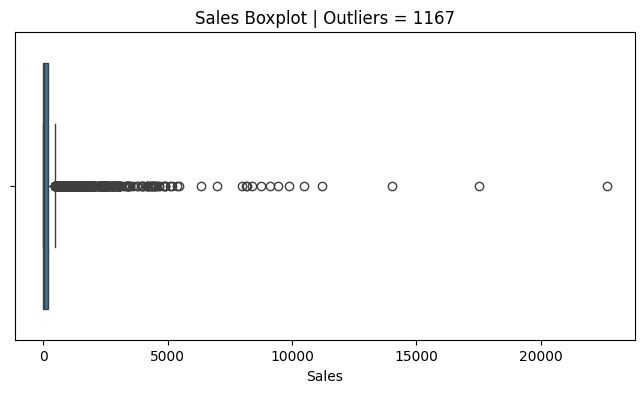

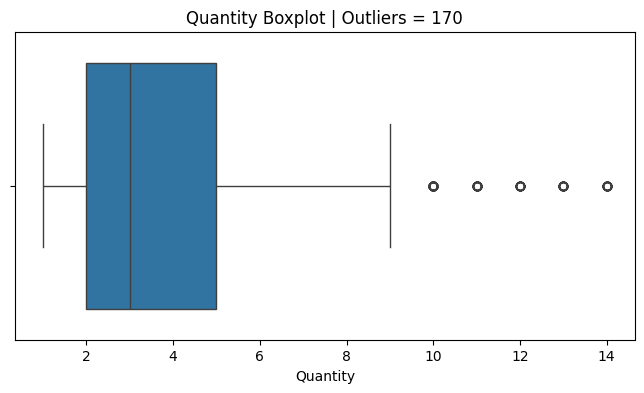

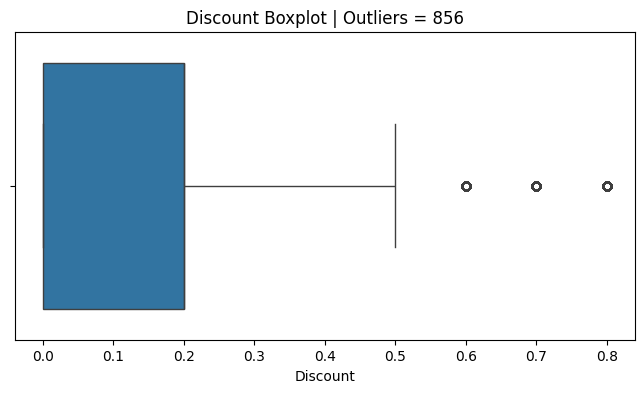

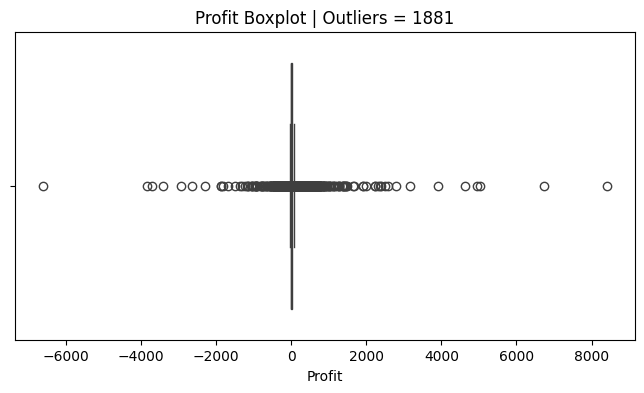

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create boxplots for every numeric column
for col in numeric_cols:

    # Calculate IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Outlier limits
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    count = outliers.shape[0]

    # Plot
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])

    plt.title(f"{col} Boxplot | Outliers = {count}")
    plt.xlabel(col)
    plt.show()

In [16]:
df["Sales_Original"] = df["Sales"]
df["Sales_Log"] = np.log1p(df["Sales"])
df.drop(columns=["Sales"], inplace=True)

Number of outliers in Sales_Log: 10
Lower Bound: -0.7628416842076922
Upper Bound: 9.020222983082164
      Sales_Original  Sales_Log
2623       11199.968   9.323755
2697       22638.480  10.027451
4098        9449.950   9.153871
4190       10499.970   9.259223
4277        9099.930   9.116132


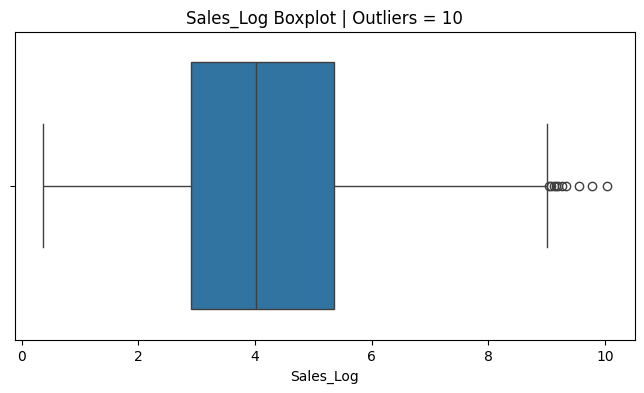

In [17]:
Q1 = df["Sales_Log"].quantile(0.25)
Q3 = df["Sales_Log"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Outliers rows
outliers = df[(df["Sales_Log"] < lower) | (df["Sales_Log"] > upper)]

# Count
print("Number of outliers in Sales_Log:", outliers.shape[0])

# Show limits
print("Lower Bound:", lower)
print("Upper Bound:", upper)

# Show some outliers
print(outliers[["Sales_Original", "Sales_Log"]].head())

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Sales_Log"])
plt.title(f"Sales_Log Boxplot | Outliers = {outliers.shape[0]}")
plt.show()

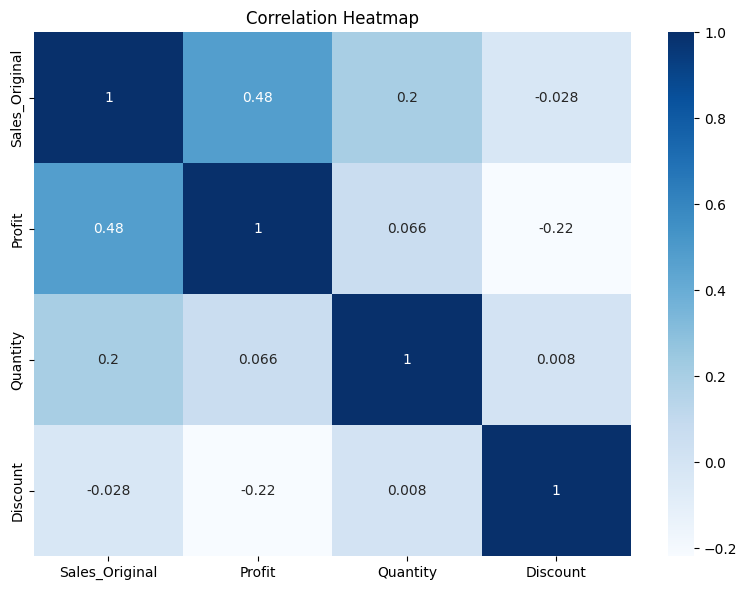

In [18]:
corr_cols = [
    "Sales_Original",
    "Profit",
    "Quantity",
    "Discount",
]
plt.figure(figsize=(8,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
cols_to_cap = ['Quantity']

for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

In [20]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1
Duplicate rows: 0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         9993 non-null   datetime64[ns]
 1   Ship Mode          9993 non-null   object        
 2   Segment            9993 non-null   object        
 3   City               9993 non-null   object        
 4   State              9993 non-null   object        
 5   Region             9993 non-null   object        
 6   Category           9993 non-null   object        
 7   Sub-Category       9993 non-null   object        
 8   Quantity           9993 non-null   float64       
 9   Discount           9993 non-null   float64       
 10  Profit             9993 non-null   float64       
 11  Discount_Category  9993 non-null   category      
 12  Sales_Original     9993 non-null   float64       
 13  Sales_Log          9993 non-null   float64       
dtypes: category(1

***

### Current State of the Dataset

The dataset is now clean, free of missing values, and the outliers have been handled appropriately. 

You will notice that some columns were **not dropped** and we have variations of the same feature (e.g., `Sales` and `Sales_Log`). This is intentional to serve both the **PowerBI/EDA** and the **Machine Learning**.

Here is the breakdown of how to use the current columns:

#### 1. For Exploratory Data Analysis (EDA) & PowerBI
If you are working on creating the dashboard or extracting business insights, please use the **Original Columns**:
* `Sales`, `Profit`, `Discount`, `Quantity`: These represent the actual business figures and are essential for accurate financial reporting.
* `Order Date`: Required for the Time Series analysis.
* **Note:** Do not use the Log or Categorical versions of these columns for visualizations, as the business owners need to see the real monetary values.

####  2. For Machine Learning
If you are working on the predictive model (Step 5), you must use the **Engineered Columns** to ensure high accuracy and avoid errors:
* Use `Sales_Log` instead of `Sales` (Target Variable - Log transformation handles extreme values).
* Use `Discount_Category` instead of `Discount` (Binning improves model understanding of clearance events).
* The `Quantity` column have already been capped (Winsorized) to handle extreme outliers safely without dropping customer records.

#### Action Required Before Training the Model:
Before feeding this DataFrame into any Machine Learning algorithm, the ML team needs to create a new dataframe (e.g., `ml_df`) and perform the following final drops:
1.  **Drop `Profit`:** (we cannot predict sales using the final profit).
2.  **Drop Originals:** Drop `Sales_Original`, `Discount`.
3.  **Apply Encoding:** Convert the remaining categorical columns (like `Category`, `Region`, `Segment`) into numerical values using One-Hot Encoding or Label Encoding.

***

In [22]:
df.to_csv('data/Walmart_Cleaned_for_BI.csv', index=False)

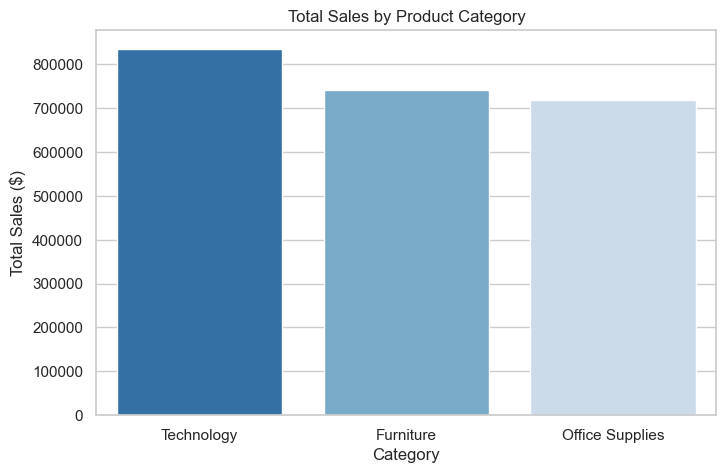

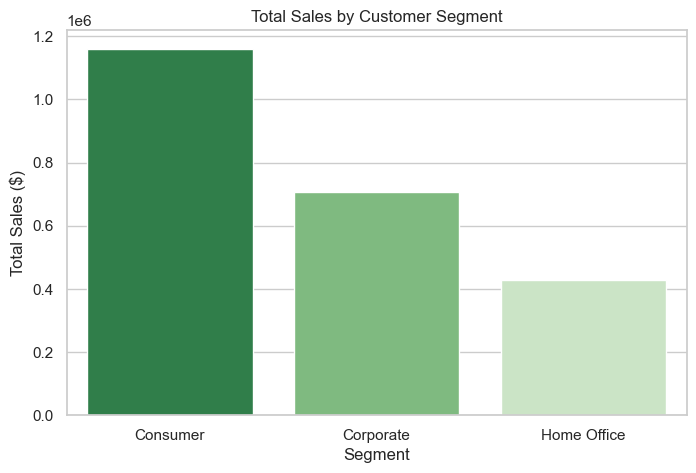

In [23]:

sns.set_theme(style="whitegrid")

#  Product Category with Highest Sales
plt.figure(figsize=(8, 5))
cat_sales = df.groupby('Category')['Sales_Original'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_sales, x='Category', y='Sales_Original',hue='Category', palette='Blues_r',legend=False)
plt.title('Total Sales by Product Category')
plt.ylabel('Total Sales ($)')
plt.show()

# Customer Segment with Highest Sales
plt.figure(figsize=(8, 5))
seg_sales = df.groupby('Segment')['Sales_Original'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=seg_sales, x='Segment', y='Sales_Original',hue='Segment', palette='Greens_r',legend=False)
plt.title('Total Sales by Customer Segment')
plt.ylabel('Total Sales ($)')
plt.show()

## Business Insights: Category, Segment, and Geography
* Based on our exploratory data visualizations, we have abled to answer the questions of the owners of the Walmart

### Product Category Performance
**Top Category:** The **Technology** category generates the highest total sales for the company.

### Customer Segment Contribution
**Top Segment:** The Consumer segment contributes the most to total sales.

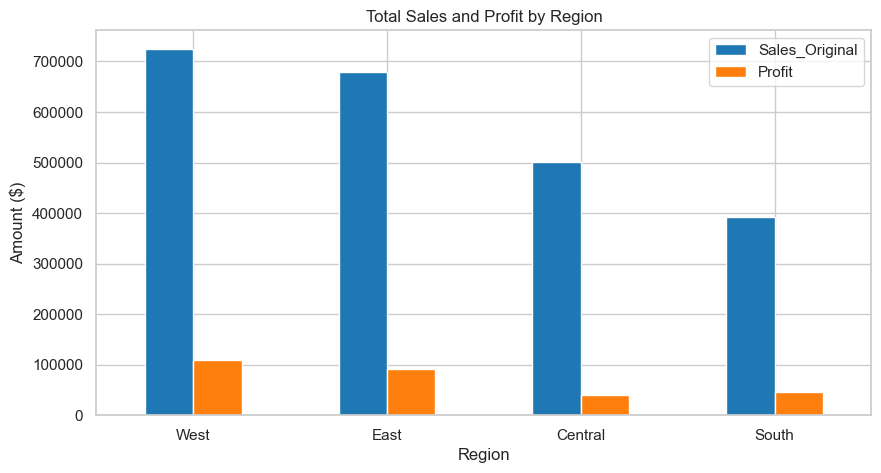

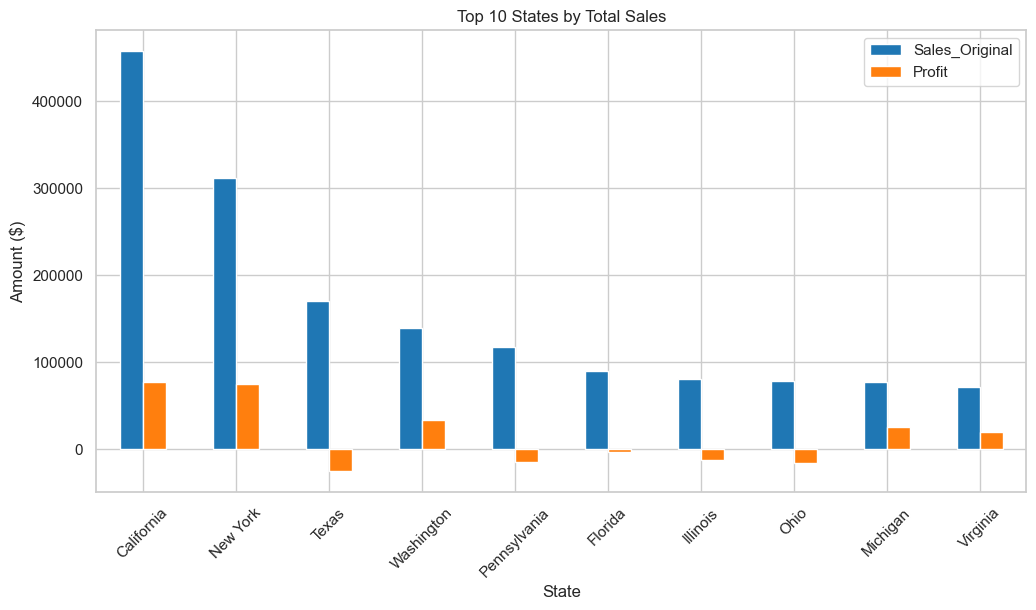

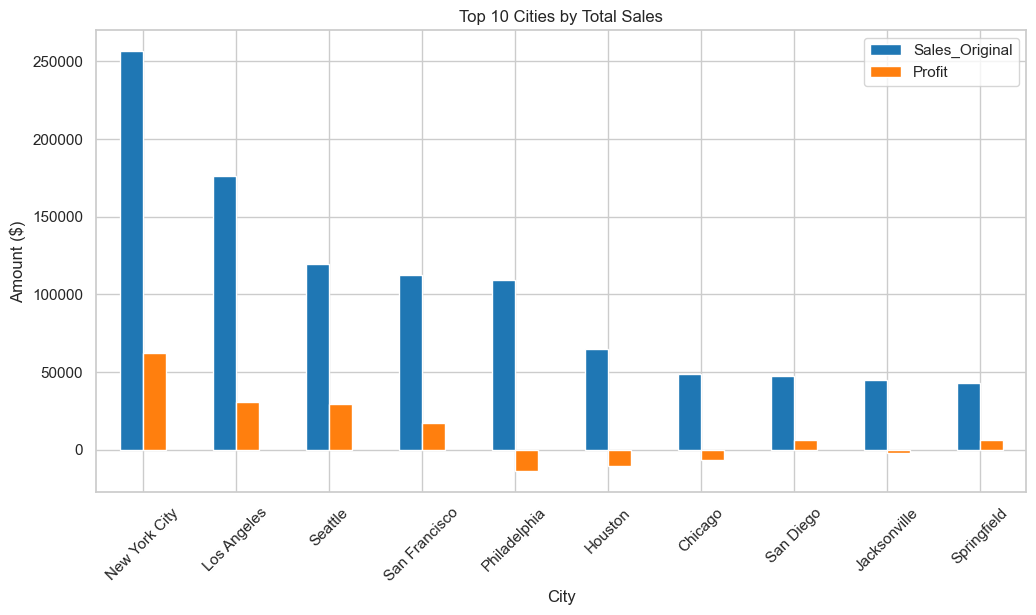

In [24]:
# 3. Top Region, State, and City by Sales & Profit

# Region
region_sp = df.groupby('Region')[['Sales_Original', 'Profit']].sum().sort_values(by='Sales_Original', ascending=False).reset_index()
region_sp.plot(x='Region', y=['Sales_Original', 'Profit'], kind='bar', figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
plt.title('Total Sales and Profit by Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.show()

# Top 10 States
state_sp = df.groupby('State')[['Sales_Original', 'Profit']].sum().sort_values(by='Sales_Original', ascending=False).head(10).reset_index()
state_sp.plot(x='State', y=['Sales_Original', 'Profit'], kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Top 10 States by Total Sales')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.show()

# Top 10 Cities
city_sp = df.groupby('City')[['Sales_Original', 'Profit']].sum().sort_values(by='Sales_Original', ascending=False).head(10).reset_index()
city_sp.plot(x='City', y=['Sales_Original', 'Profit'], kind='bar', figsize=(12, 6), color=['#1f77b4', '#ff7f0e'])
plt.title('Top 10 Cities by Total Sales')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.show()

### Geographic Performance (Region, State, and City)
* **Top Region:** The **West** region leads the country in overall sales and profit.
* **Top State:** **California** is our highest-performing state, bringing in approximately $470,000 in revenue and $70,000 in profit.
* **Top City:** At the localized level, **New York City** acts as our strongest individual market.

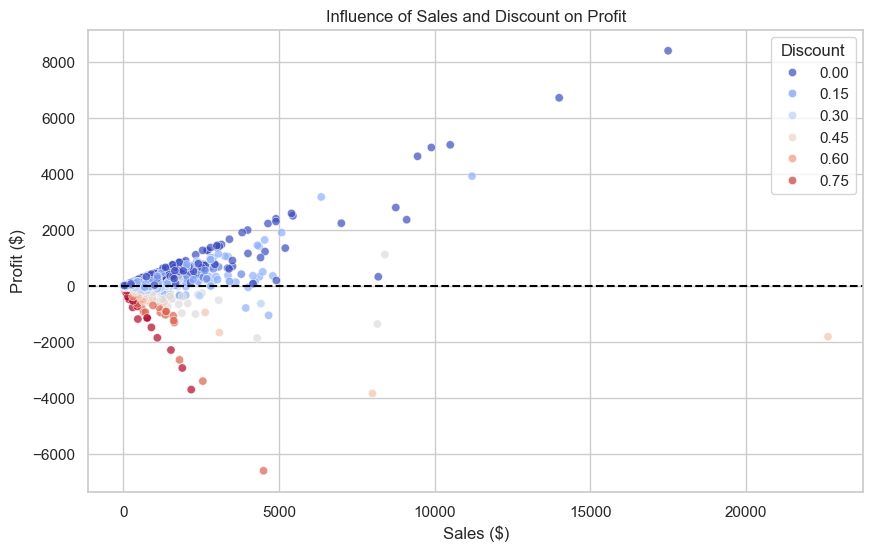

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Sales_Original', y='Profit', hue='Discount', palette='coolwarm', alpha=0.7)

plt.title('Influence of Sales and Discount on Profit')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')

# Draw a line at Profit = 0 to clearly see what causes a loss
plt.axhline(0, color='black', linestyle='--') 
plt.show()

## The Impact of Discounts on Profitability

Our analysis reveals a critical vulnerability in the current pricing strategy: high revenue does not guarantee high profit if discounts are too steep.

*   **The Danger Zone (≥ 45% Discount):** Discounts of 45% or higher almost exclusively result in a net loss, regardless of total sales volume (e.g., one heavily discounted $23,000 sale resulted in a $2,000 loss).
*   **The Healthy Zone (0% - 20% Discount):** Sales within this range scale predictably and profitably (e.g., our most profitable transaction generated $8,000 in pure profit with a 0% discount).
*   **Strategic Recommendation:** **Cap standard discounts at 30%.** Offering discounts beyond 30% actively destroys profit margins, even when it successfully drives top-line revenue.

# Encoding & Normalization 

In [26]:
ml_df = df.copy()
ml_df.drop(columns=['Profit','Sales_Original', 'Discount'], inplace=True)

In [27]:
discount_order = ["No Discount", "Low Discount", "Medium Discount", "High Discount"]
ml_df["Discount_Category"] = ml_df["Discount_Category"].astype(str)
ml_df["Discount_Category"] = ml_df["Discount_Category"].map(
    {label: i for i, label in enumerate(discount_order)}
)
print("Discount_Category ordinal mapping:", {label: i for i, label in enumerate(discount_order)})
print(ml_df["Discount_Category"].value_counts())

Discount_Category ordinal mapping: {'No Discount': 0, 'Low Discount': 1, 'Medium Discount': 2, 'High Discount': 3}
Discount_Category
0    4749
1    3852
3     856
2     536
Name: count, dtype: int64


In [28]:
ml_df["Order_Year"]       = ml_df["Order Date"].dt.year
ml_df["Order_Month"]      = ml_df["Order Date"].dt.month
ml_df["Order_DayOfWeek"]  = ml_df["Order Date"].dt.dayofweek  # 0=Monday, 6=Sunday
ml_df.drop(columns=["Order Date"], inplace=True)

In [29]:
duplicates = ml_df[ml_df.duplicated(keep=False)]

print("Here are the duplicate rows:")
print(duplicates)
print(duplicates.count())
ml_df.drop_duplicates(inplace=True)

Here are the duplicate rows:
         Ship Mode    Segment        City     State Region         Category  \
3276  Second Class  Corporate  Alexandria  Virginia  South  Office Supplies   
3279  Second Class  Corporate  Alexandria  Virginia  South  Office Supplies   

     Sub-Category  Quantity  Discount_Category  Sales_Log  Order_Year  \
3276          Art       7.0                  0   3.176386        2014   
3279          Art       7.0                  0   3.176386        2014   

      Order_Month  Order_DayOfWeek  
3276            4                5  
3279            4                5  
Ship Mode            2
Segment              2
City                 2
State                2
Region               2
Category             2
Sub-Category         2
Quantity             2
Discount_Category    2
Sales_Log            2
Order_Year           2
Order_Month          2
Order_DayOfWeek      2
dtype: int64


In [30]:
ml_df.info()
ml_df.nunique()

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ship Mode          9992 non-null   object 
 1   Segment            9992 non-null   object 
 2   City               9992 non-null   object 
 3   State              9992 non-null   object 
 4   Region             9992 non-null   object 
 5   Category           9992 non-null   object 
 6   Sub-Category       9992 non-null   object 
 7   Quantity           9992 non-null   float64
 8   Discount_Category  9992 non-null   int64  
 9   Sales_Log          9992 non-null   float64
 10  Order_Year         9992 non-null   int32  
 11  Order_Month        9992 non-null   int32  
 12  Order_DayOfWeek    9992 non-null   int32  
dtypes: float64(2), int32(3), int64(1), object(7)
memory usage: 975.8+ KB


Ship Mode               4
Segment                 3
City                  531
State                  50
Region                  4
Category                3
Sub-Category           17
Quantity               10
Discount_Category       4
Sales_Log            5825
Order_Year              4
Order_Month            12
Order_DayOfWeek         7
dtype: int64

In [31]:
# Do City and State actually drive sales, or are they just noise?
print("--- Variance in Sales by State ---")
print(ml_df.groupby('State')['Sales_Log'].mean().describe())

#  How is Quantity distributed after capping the outliers?
print("\n--- Quantity Distribution ---")
print(ml_df['Quantity'].describe())

--- Variance in Sales by State ---
count    50.000000
mean      4.285287
std       0.553476
min       3.269970
25%       4.002460
50%       4.311728
75%       4.421452
max       7.380341
Name: Sales_Log, dtype: float64

--- Quantity Distribution ---
count    9992.000000
mean        3.753203
std         2.102443
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max         9.500000
Name: Quantity, dtype: float64


In [32]:
print("\n--- Avg Sales by Sub-Category ---")
print(ml_df.groupby('Sub-Category')['Sales_Log'].mean().sort_values())


--- Avg Sales by Sub-Category ---
Sub-Category
Fasteners      2.433132
Labels         2.911213
Art            2.943740
Binders        3.233593
Paper          3.500799
Envelopes      3.570965
Supplies       3.610278
Furnishings    3.855532
Appliances     4.504562
Accessories    4.680797
Storage        4.830590
Phones         5.254851
Bookcases      5.792182
Chairs         5.870004
Tables         6.086460
Machines       6.482100
Copiers        7.167050
Name: Sales_Log, dtype: float64


In [33]:
from sklearn.preprocessing import StandardScaler

# Drop the noisy columns
ml_df.drop(columns=['City', 'State'], inplace=True)

# label Encode 'Ship Mode' (Based on delivery speed)
ship_mapping = {
    'Standard Class': 0,
    'Second Class': 1,
    'First Class': 2,
    'Same Day': 3
}
ml_df['Ship Mode'] = ml_df['Ship Mode'].map(ship_mapping)

# label Encode 'Sub-Category' (Based on your average sales output)
subcat_mapping = {
    'Fasteners': 0, 'Labels': 1, 'Art': 2, 'Binders': 3, 
    'Paper': 4, 'Envelopes': 5, 'Supplies': 6, 'Furnishings': 7, 
    'Appliances': 8, 'Accessories': 9, 'Storage': 10, 'Phones': 11, 
    'Bookcases': 12, 'Chairs': 13, 'Tables': 14, 'Machines': 15, 'Copiers': 16
}
ml_df['Sub-Category'] = ml_df['Sub-Category'].map(subcat_mapping)

# 4. One-Hot Encode the remaining low-cardinality categoricals
# (Segment, Region, Category)
ml_df = pd.get_dummies(ml_df, columns=['Segment', 'Region', 'Category'], drop_first=True, dtype=int)

# 5. Scale the 'Quantity' column (normalization)
scaler = StandardScaler()
ml_df['Quantity'] = scaler.fit_transform(ml_df[['Quantity']])

print(ml_df.info())
print("\nFirst 5 rows:")
display(ml_df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 9992 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ship Mode                 9992 non-null   int64  
 1   Sub-Category              9992 non-null   int64  
 2   Quantity                  9992 non-null   float64
 3   Discount_Category         9992 non-null   int64  
 4   Sales_Log                 9992 non-null   float64
 5   Order_Year                9992 non-null   int32  
 6   Order_Month               9992 non-null   int32  
 7   Order_DayOfWeek           9992 non-null   int32  
 8   Segment_Corporate         9992 non-null   int64  
 9   Segment_Home Office       9992 non-null   int64  
 10  Region_East               9992 non-null   int64  
 11  Region_South              9992 non-null   int64  
 12  Region_West               9992 non-null   int64  
 13  Category_Office Supplies  9992 non-null   int64  
 14  Category_Tech

,Ship Mode,Sub-Category,Quantity,Discount_Category,Sales_Log,Order_Year,Order_Month,Order_DayOfWeek,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology
0,1,12,-0.833930,0,5.572002,2016,11,1,0,0,0,1,0,0,0
1,1,13,-0.358269,0,6.597064,2016,11,1,0,0,0,1,0,0,0
2,1,1,-0.833930,0,2.748552,2016,6,6,1,0,0,0,1,1,0
3,0,14,0.593053,2,6.865450,2015,10,6,0,0,0,1,0,0,0
4,0,10,-0.833930,1,3.151368,2015,10,6,0,0,0,1,0,1,0


## Recap

### 1. Dimensionality Reduction (Dropping Columns)
**`City` (531 unique)**
High-cardinality categorical features cause the "Curse of Dimensionality" when One-Hot Encoded, bloating the dataset with hundreds of sparse columns.

**`State` (50 unique):**(low standard deviation in average sales) indicating low predictive power The standard deviation of the means is only 0.55. While there is some variance between the highest and lowest states, spreading our data across 50 dummy columns will cause more noise than it's worth.

We dropped both and kept `Region` to represent geography cleanly.
### 2. label Encoding
the categorical feature that has a logical, mathematical hierarchy.
* **`Ship Mode`:** Encoded based on delivery speed and implied cost (Standard = 0, Second = 1, First = 2, Same Day = 3).
* **`Sub-Category`:** Exploratory Data Analysis (EDA) revealed a strict, monotonic relationship between Sub-Category and average `Sales_Log` (ranging from Fasteners at the bottom to Copiers at the top). By mapping these to integers (0 to 16) based on this rank, we feed the model a direct mathematical trend without adding 17 new dummy columns.

### 3. One-Hot Encoding
* **`Segment`, `Region`, `Category`:** These features have no inherent mathematical order (e.g., "Furniture" is not mathematically greater than "Technology"). We converted them into binary columns (0s and 1s).
* **Avoiding the Dummy Variable Trap:** We applied `drop_first=True` to remove one baseline column per category. This prevents perfect multicollinearity, keeping the dataset leaner and mathematically stable.

### 4. Feature Scaling 
* **`Quantity` (StandardScaler):** We applied Z-Score Normalization (`StandardScaler`) to center the `Quantity` distribution around a mean of 0 with a standard deviation of 1. 
* *Why not MinMaxScaler?* MinMaxScaler squishes data strictly between 0 and 1, making it highly vulnerable to being crushed by extreme outliers. StandardScaler preserves the natural shape and variance of the data, making it the safer, more robust choice for numerical scaling.

In [34]:
ml_df.to_csv('data/Walmart_Cleaned_for_Model.csv', index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

X = ml_df.drop("Sales_Log", axis=1)
y = ml_df["Sales_Log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

##Ev The Model 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2  :", r2)

MAE : 0.8720169030308199
MSE : 1.261754040704616
RMSE: 1.1232782561345234
MAPE: 0.2505866506755604
R2  : 0.5110987707697627


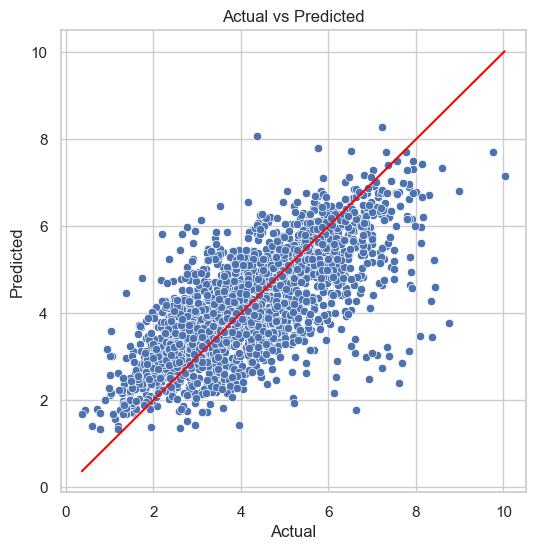

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

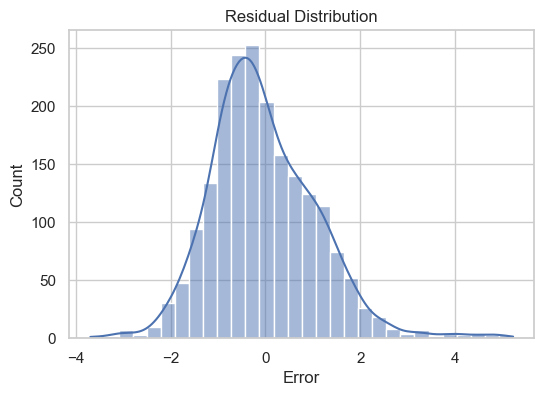

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

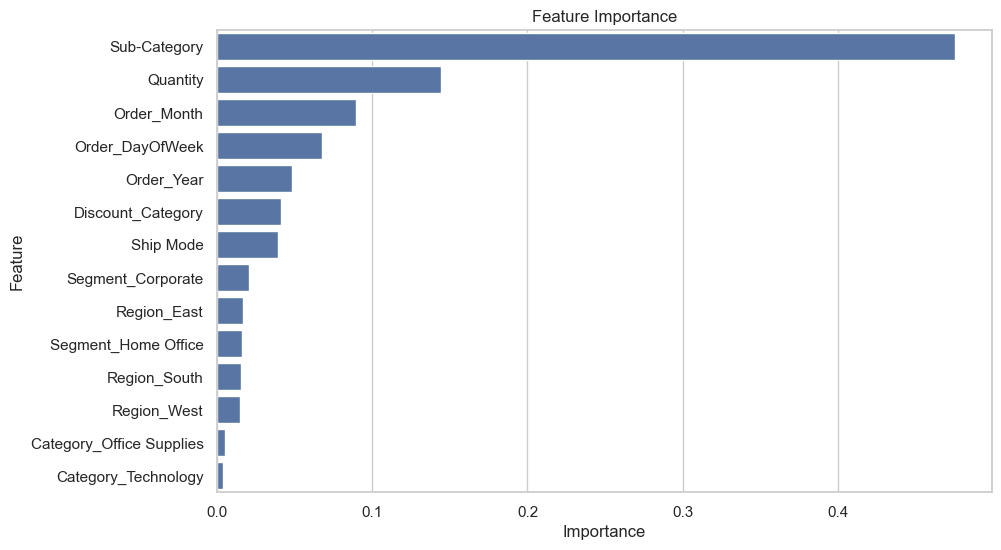

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

In [37]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Split
X = ml_df.drop("Sales_Log", axis=1)
y = ml_df["Sales_Log"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Prediction
y_pred = xgb_model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.8517158421452831
R2 Score: 0.5367392812001517
